# Portfolio Project: Online Retail Exploratory Data Analysis with Python

## Overview

In this project, you will step into the shoes of an entry-level data analyst at an online retail company, helping interpret real-world data to help make a key business decision.

## Case Study
In this project, you will be working with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps. Your task is to explore and analyze this dataset to gain insights into the store's sales trends, customer behavior, and popular products. 

By conducting exploratory data analysis, you will identify patterns, outliers, and correlations in the data, allowing you to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction. Through visualizations and statistical analysis, you will uncover key trends, such as the busiest sales months, best-selling products, and the store's most valuable customers. Ultimately, this project aims to provide actionable insights that can drive strategic business decisions and enhance the store's overall performance in the competitive online retail market.

## Prerequisites

Before starting this project, you should have some basic knowledge of Python programming and Pandas. In addition, you may want to use the following packages in your Python environment:

- pandas
- numpy
- seaborn
- matplotlib

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install pandas`
- `!pip install matplotlib`

## Project Objectives
1. Describe data to answer key questions to uncover insights
2. Gain valuable insights that will help improve online retail performance
3. Provide analytic insights and data-driven recommendations

## Dataset

The dataset you will be working with is the "Online Retail" dataset. It contains transactional data of an online retail store from 2010 to 2011. The dataset is available as a .xlsx file named `Online Retail.xlsx`. This data file is already included in the Coursera Jupyter Notebook environment, however if you are working off-platform it can also be downloaded [here](https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx).

The dataset contains the following columns:

- InvoiceNo: Invoice number of the transaction
- StockCode: Unique code of the product
- Description: Description of the product
- Quantity: Quantity of the product in the transaction
- InvoiceDate: Date and time of the transaction
- UnitPrice: Unit price of the product
- CustomerID: Unique identifier of the customer
- Country: Country where the transaction occurred

## Tasks

You may explore this dataset in any way you would like - however if you'd like some help getting started, here are a few ideas:

1. Load the dataset into a Pandas DataFrame and display the first few rows to get an overview of the data.
2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3. Explore the basic statistics of the dataset, including measures of central tendency and dispersion.
4. Perform data visualization to gain insights into the dataset. Generate appropriate plots, such as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
5. Analyze the sales trends over time. Identify the busiest months and days of the week in terms of sales.
6. Explore the top-selling products and countries based on the quantity sold.
7. Identify any outliers or anomalies in the dataset and discuss their potential impact on the analysis.
8. Draw conclusions and summarize your findings from the exploratory data analysis.

## Task 1: Load the Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)

In [2]:
df = pd.read_excel("Online Retail.xlsx")
# To display the top 5 rows 
df.head(5)      

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (5268, 8)


In [5]:
print(df.isnull().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:


# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values
# Drop rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

# Fill missing descriptions with 'Unknown'
df["Description"] = df["Description"].fillna("Unknown")

# Remove redundant or unnecessary columns (if any)
# Example: remove columns with all missing values
df = df.dropna(axis=1, how="all")

# Reset index after cleaning
df = df.reset_index(drop=True)


In [7]:
df.shape

(401604, 8)

In [8]:


# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Basic statistics (count, mean, std, min, 25%, 50%, 75%, max)
basic_stats = numerical_cols.describe()

# Measures of central tendency
mean = numerical_cols.mean()
median = numerical_cols.median()

# Measures of dispersion
std_dev = numerical_cols.std()
variance = numerical_cols.var()
range_values = numerical_cols.max() - numerical_cols.min()

# Display results
print("Basic Statistics:\n", basic_stats)
print("\nMean:\n", mean)
print("\nMedian:\n", median)
print("\nStandard Deviation:\n", std_dev)
print("\nVariance:\n", variance)
print("\nRange:\n", range_values)

Basic Statistics:
             Quantity      UnitPrice     CustomerID
count  401604.000000  401604.000000  401604.000000
mean       12.183273       3.474064   15281.160818
std       250.283037      69.764035    1714.006089
min    -80995.000000       0.000000   12346.000000
25%         2.000000       1.250000   13939.000000
50%         5.000000       1.950000   15145.000000
75%        12.000000       3.750000   16784.000000
max     80995.000000   38970.000000   18287.000000

Mean:
 Quantity         12.183273
UnitPrice         3.474064
CustomerID    15281.160818
dtype: float64

Median:
 Quantity          5.00
UnitPrice         1.95
CustomerID    15145.00
dtype: float64

Standard Deviation:
 Quantity       250.283037
UnitPrice       69.764035
CustomerID    1714.006089
dtype: float64

Variance:
 Quantity      6.264160e+04
UnitPrice     4.867021e+03
CustomerID    2.937817e+06
dtype: float64

Range:
 Quantity      161990.0
UnitPrice      38970.0
CustomerID      5941.0
dtype: float64


In [9]:
# Load and clean the Online Retail.xlsx file: show head, handle missing values, drop redundant columns
# This cell reads the Excel file, displays head, shows missing value counts, performs cleaning (drop rows with missing CustomerID and InvoiceNo?), and drops unnecessary columns if any

from tqdm import tqdm

# read the sheet
df = pd.read_excel('Online Retail.xlsx', sheet_name='Online Retail')

# show initial head and missing counts
print(df.head())
print(df.isnull().sum())

# Cleaning strategy (assumptions):
# - InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
# - Remove rows with missing CustomerID because customer-level analysis often needs ID
# - Remove rows with missing Description as not useful
# - Convert InvoiceDate from excel timestamp if necessary (it seems numeric in preview)
# - Remove cancellations: InvoiceNo starting with C (if present)

# Convert InvoiceDate if it's numeric (ms since epoch) - detect type
if pd.api.types.is_integer_dtype(df['InvoiceDate']) or pd.api.types.is_float_dtype(df['InvoiceDate']):
    try:
        df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], unit='ms')
    except Exception:
        try:
            df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
        except Exception:
            pass

# Drop rows with missing CustomerID or Description
clean_df = df.copy()
clean_df = clean_df.dropna(subset=['CustomerID', 'Description'])

# Remove cancelled invoices (InvoiceNo as string starting with C)
clean_df['InvoiceNo'] = clean_df['InvoiceNo'].astype(str)
clean_df = clean_df[~clean_df['InvoiceNo'].str.startswith('C')]

# Remove duplicate exact rows
before_duplicates = len(clean_df)
clean_df = clean_df.drop_duplicates()
after_duplicates = len(clean_df)

# Identify any redundant columns: none obvious, but if StockCode numeric, keep it. We'll keep all except maybe drop unnamed index columns
redundant_cols = [c for c in clean_df.columns if 'unnamed' in c.lower()]
clean_df = clean_df.drop(columns=redundant_cols)

# Show results
print('\
After cleaning:')
print(clean_df.head())
print(clean_df.isnull().sum())
print('Rows before cleaning:', len(df))
print('Rows after cleaning:', len(clean_df))
print('Duplicates removed:', before_duplicates - after_duplicates)

# Save cleaned file
clean_filename = 'Online_Retail_cleaned.csv'
clean_df.to_csv(clean_filename, index=False)
print('Saved cleaned file to ' + clean_filename)

# Keep dataframe in memory as required
df = clean_df



  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [10]:

# Load a manageable sample
file_path = "Online Retail.xlsx"
df = pd.read_excel(file_path)

# Remove invalid values
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove outliers using IQR method
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df_clean = remove_outliers_iqr(df_clean, 'Quantity')
df_clean = remove_outliers_iqr(df_clean, 'UnitPrice')

# Display new basic statistics
clean_stats = df_clean[['Quantity', 'UnitPrice']].describe()

clean_stats


,Quantity,UnitPrice
count,442666.000000,442666.000000
mean,4.904070,2.784289
std,4.495069,2.036175
min,1.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,8.000000,3.750000
max,23.000000,8.500000


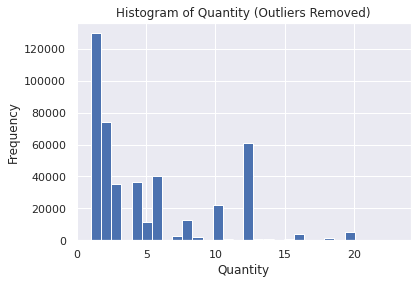

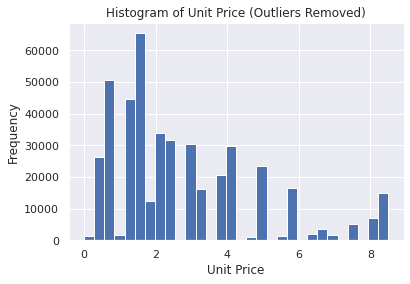

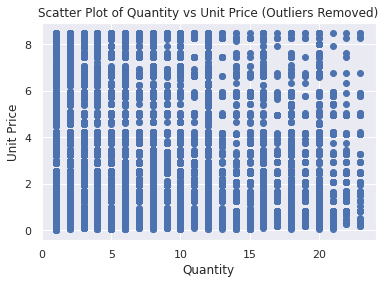

In [6]:
# Histogram of Cleaned Quantity
plt.figure()
plt.hist(df_clean['Quantity'], bins=30)
plt.title("Histogram of Quantity (Outliers Removed)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# Histogram of Cleaned Unit Price
plt.figure()
plt.hist(df_clean['UnitPrice'], bins=30)
plt.title("Histogram of Unit Price (Outliers Removed)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

# Scatter plot after outlier removal
plt.figure()
plt.scatter(df_clean['Quantity'], df_clean['UnitPrice'])
plt.title("Scatter Plot of Quantity vs Unit Price (Outliers Removed)")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()


           Quantity  UnitPrice   Revenue
Quantity   1.000000  -0.001235  0.886681
UnitPrice -0.001235   1.000000 -0.162029
Revenue    0.886681  -0.162029  1.000000


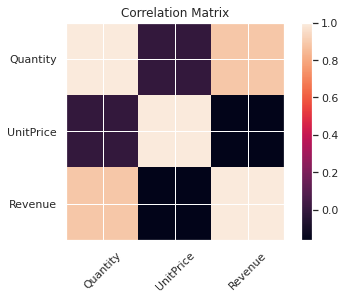

In [11]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Select numeric columns for correlation
numeric_cols = df[['Quantity', 'UnitPrice', 'Revenue']]

# Compute correlation matrix
correlation_matrix = numeric_cols.corr()

print(correlation_matrix)



# Visualize correlation matrix using matplotlib (no seaborn)

plt.figure()
plt.imshow(correlation_matrix)
plt.title("Correlation Matrix")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()


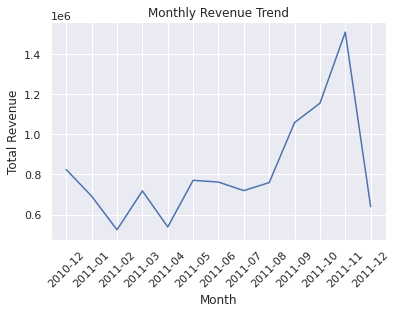

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,7,4310.00,4,4,4,12
12348.0,75,4,1797.24,2,3,4,9
12349.0,19,1,1757.55,3,1,4,8
12350.0,310,1,334.40,1,1,2,4


In [9]:


# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Clean data (remove negatives and zero prices)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# -----------------------------
# TIME-SERIES ANALYSIS
# -----------------------------

# Extract Year-Month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

# Plot Monthly Revenue Trend
plt.figure()
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# RFM ANALYSIS
# -----------------------------

# Remove rows without CustomerID
df_rfm = df.dropna(subset=['CustomerID'])

# Snapshot date (one day after last invoice)
snapshot_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM metrics
rfm = df_rfm.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'Revenue': 'sum'                                           # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# RFM Scoring using quartiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

rfm.head()


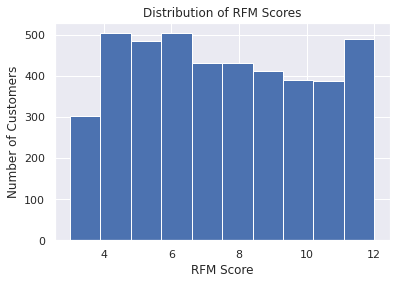

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
14646.0,2,73,280206.02,4,4,4,12
18102.0,1,60,259657.30,4,4,4,12
17450.0,8,46,194550.79,4,4,4,12
16446.0,1,2,168472.50,4,2,4,10
14911.0,1,201,143825.06,4,4,4,12
12415.0,24,21,124914.53,3,4,4,11
14156.0,10,55,117379.63,4,4,4,12
17511.0,3,31,91062.38,4,4,4,12
16029.0,39,63,81024.84,3,4,4,11


In [10]:
# -----------------------------
#  Visualize RFM Distribution
# -----------------------------

plt.figure()
plt.hist(rfm['RFM_Score'], bins=10)
plt.title("Distribution of RFM Scores")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.show()


# -----------------------------
#  Top 10 High-Value Customers
# -----------------------------

top_10_customers = rfm.sort_values(by='Monetary', ascending=False).head(10)

top_10_customers

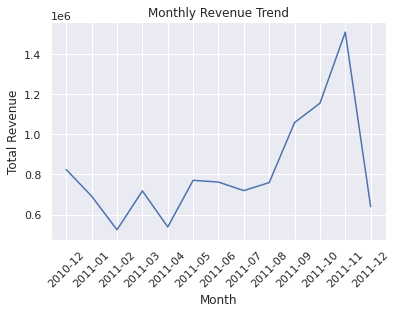

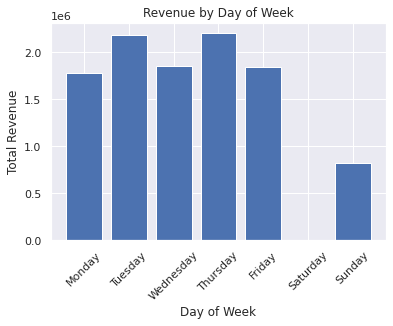

(Period('2011-11', 'M'), 1509496.329999743, 'Thursday', 2203161.2399997725)

In [11]:

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Clean data
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# -----------------------------
# Monthly Sales Trend
# -----------------------------

df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure()
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

# Identify busiest month
busiest_month = monthly_sales.idxmax()
busiest_month_value = monthly_sales.max()

# -----------------------------
# Day of Week Analysis
# -----------------------------

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
daily_sales = df.groupby('DayOfWeek')['Revenue'].sum()

# Reorder days properly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales = daily_sales.reindex(days_order)

plt.figure()
plt.bar(daily_sales.index, daily_sales.values)
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

# Identify busiest day
busiest_day = daily_sales.idxmax()
busiest_day_value = daily_sales.max()

busiest_month, busiest_month_value, busiest_day, busiest_day_value


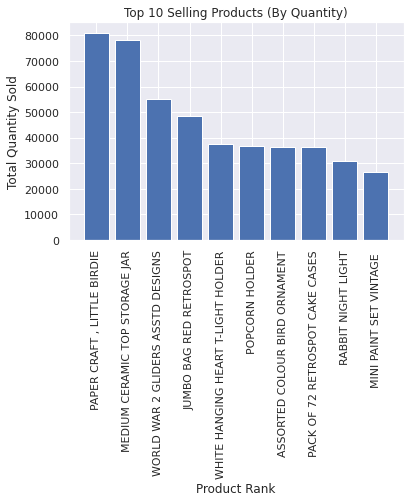

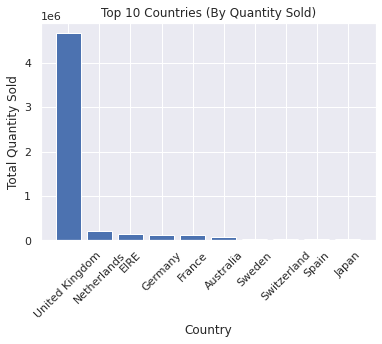

(StockCode  Description                       
 23843      PAPER CRAFT , LITTLE BIRDIE           80995
 23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
 84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
 85099B     JUMBO BAG RED RETROSPOT               48474
 85123A     WHITE HANGING HEART T-LIGHT HOLDER    37599
 22197      POPCORN HOLDER                        36761
 84879      ASSORTED COLOUR BIRD ORNAMENT         36461
 21212      PACK OF 72 RETROSPOT CAKE CASES       36419
 23084      RABBIT NIGHT LIGHT                    30788
 22492      MINI PAINT SET VINTAGE                26633
 Name: Quantity, dtype: int64,
 Country
 United Kingdom    4662390
 Netherlands        200361
 EIRE               147173
 Germany            119261
 France             112103
 Australia           83901
 Sweden              36083
 Switzerland         30629
 Spain               27940
 Japan               26016
 Name: Quantity, dtype: int64)

In [12]:


# Data cleaning
df = df[(df['Quantity'] > 0)]

# -----------------------------
# Top-Selling Products (by Quantity)
# -----------------------------

top_products = (
    df.groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot top products
plt.figure()
plt.bar(range(len(top_products)), top_products.values)
plt.title("Top 10 Selling Products (By Quantity)")
plt.xlabel("Product Rank")
plt.ylabel("Total Quantity Sold")
plt.xticks(range(len(top_products)), top_products.index.get_level_values(1), rotation=90)
plt.show()

# -----------------------------
# Top Countries (by Quantity)
# -----------------------------

top_countries_qty = (
    df.groupby('Country')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot top countries
plt.figure()
plt.bar(top_countries_qty.index, top_countries_qty.values)
plt.title("Top 10 Countries (By Quantity Sold)")
plt.xlabel("Country")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

top_products, top_countries_qty


In [14]:
!pip install python-pptx

     |████████████████████████████████| 471 kB 27.9 MB/s            
     |████████████████████████████████| 165 kB 114.7 MB/s            
     |████████████████████████████████| 4.9 MB 69.9 MB/s            
You should consider upgrading via the '/opt/conda/bin/python3 -m pip install --upgrade pip' command.


In [17]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_AUTO_SHAPE_TYPE
from pptx.util import Cm



# Data cleaning
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# =============================
# KPI Calculations
# =============================
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = total_revenue / total_orders

# Monthly revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()

# Save monthly revenue chart
plt.figure()
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
monthly_chart_path = "monthly_trend.png"
plt.savefig(monthly_chart_path)
plt.close()

# Revenue by Day of Week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales = df.groupby('DayOfWeek')['Revenue'].sum().reindex(days_order)

plt.figure()
plt.bar(daily_sales.index, daily_sales.values)
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
daily_chart_path = "daily_trend.png"
plt.savefig(daily_chart_path)
plt.close()

# Top 5 products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)

plt.figure()
plt.bar(top_products.index, top_products.values)
plt.title("Top 5 Products by Quantity Sold")
plt.xticks(rotation=45)
products_chart_path = "top_products.png"
plt.savefig(products_chart_path)
plt.close()

# =============================
# Create PowerPoint Dashboard
# =============================
prs = Presentation()

# Slide 1: Title Slide
slide_layout = prs.slide_layouts[0]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Online Retail Sales Dashboard"
subtitle = slide.placeholders[1]
subtitle.text = "Summary of Key Insights from Exploratory Data Analysis"

# Slide 2: KPI Summary
slide_layout = prs.slide_layouts[1]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Key Performance Indicators"

content = slide.placeholders[1]
content.text = (
    f"Total Revenue: {total_revenue:,.0f}\n"
    f"Total Orders: {total_orders:,}\n"
    f"Total Customers: {total_customers:,}\n"
    f"Average Order Value: {avg_order_value:,.2f}"
)

# Slide 3: Monthly Trend
slide = prs.slides.add_slide(prs.slide_layouts[5])
slide.shapes.title.text = "Monthly Revenue Trend"
slide.shapes.add_picture(monthly_chart_path, Inches(1), Inches(1.5), width=Inches(8))

# Slide 4: Revenue by Day
slide = prs.slides.add_slide(prs.slide_layouts[5])
slide.shapes.title.text = "Revenue by Day of Week"
slide.shapes.add_picture(daily_chart_path, Inches(1), Inches(1.5), width=Inches(8))

# Slide 5: Top Products
slide = prs.slides.add_slide(prs.slide_layouts[5])
slide.shapes.title.text = "Top 5 Selling Products"
slide.shapes.add_picture(products_chart_path, Inches(1), Inches(1.5), width=Inches(8))

# Save presentation
dashboard_path = "Online_Retail_Dashboard.pptx"
prs.save(dashboard_path)

dashboard_path


'Online_Retail_Dashboard.pptx'

In [27]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import base64
from io import BytesIO
import pypandoc



# Data cleaning
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# =============================
# KPI Calculations
# =============================
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = total_revenue / total_orders

# =============================
# Create Charts and Convert to Base64
# =============================

def plot_to_base64(plot_func):
    buffer = BytesIO()
    plot_func()
    plt.savefig(buffer, format='png')
    plt.close()
    buffer.seek(0)
    return base64.b64encode(buffer.read()).decode('utf-8')

# Monthly Revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()

def monthly_plot():
    plt.figure()
    plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
    plt.title("Monthly Revenue Trend")
    plt.xticks(rotation=45)

monthly_img = plot_to_base64(monthly_plot)

# Revenue by Day
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_sales = df.groupby('DayOfWeek')['Revenue'].sum().reindex(days_order)

def daily_plot():
    plt.figure()
    plt.bar(daily_sales.index, daily_sales.values)
    plt.title("Revenue by Day of Week")
    plt.xticks(rotation=45)

daily_img = plot_to_base64(daily_plot)

# Top Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)

def product_plot():
    plt.figure()
    plt.bar(top_products.index, top_products.values)
    plt.title("Top 5 Products by Quantity Sold")
    plt.xticks(rotation=45)

product_img = plot_to_base64(product_plot)



# Save directly as HTML 
output_path = "Online_Retail_Dashboard_Web.html"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(f"""
<!DOCTYPE html>
<html>
<head>
    <title>Online Retail Dashboard</title>
    <meta charset="UTF-8">
</head>
<body>

<h1>Online Retail Sales Dashboard</h1>

<h2>Key Performance Indicators</h2>
<ul>
    <li><b>Total Revenue:</b> {total_revenue:,.0f}</li>
    <li><b>Total Orders:</b> {total_orders:,}</li>
    <li><b>Total Customers:</b> {total_customers:,}</li>
    <li><b>Average Order Value:</b> {avg_order_value:,.2f}</li>
</ul>

<hr>

<h2>Monthly Revenue Trend</h2>
<img src="data:image/png;base64,{monthly_img}" width="400">

<hr>

<h2>Revenue by Day of Week</h2>
<img src="data:image/png;base64,{daily_img}" width="400">

<hr>

<h2>Top 5 Selling Products</h2>
<img src="data:image/png;base64,{product_img}" width="400">

</body>
</html>
""")

print("Dashboard saved successfully!")


Dashboard saved successfully!
